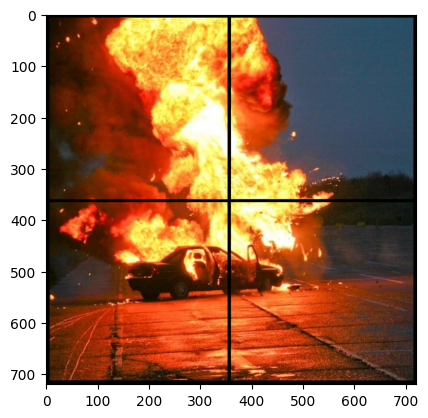

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import cv2

meledak = cv2.imread('Assets/meledak.png', cv2.IMREAD_COLOR_RGB)


plt.imshow(meledak)

In [3]:
size = meledak.shape
height = size[0]
weight = size[1]

print(height, weight)

720 720


(np.float64(-0.5), np.float64(359.5), np.float64(352.5), np.float64(-0.5))

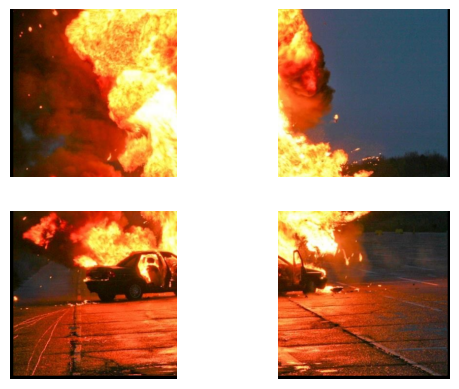

In [4]:
def Potong(gambar, a, b, mode='H'):
    return gambar[a:b, :] if mode == 'H' else gambar[:, a:b]

atas = Potong(meledak, 7, 360)
bawah = Potong(meledak, 367, 720)
kiri_atas = Potong(atas, 0, 350, 'V')
kanan_atas = Potong(atas, 360, 720, 'V')
kiri_bawah = Potong(bawah, 0, 350, 'V')
kanan_bawah = Potong(bawah, 360, 720, 'V')


plt.subplot(2,2,1)
plt.imshow(kiri_atas)
plt.axis('off')
plt.subplot(2,2,2)
plt.imshow(kanan_atas)
plt.axis('off')
plt.subplot(2,2,3)
plt.imshow(kiri_bawah)
plt.axis('off')
plt.subplot(2,2,4)
plt.imshow(kanan_bawah)
plt.axis('off')

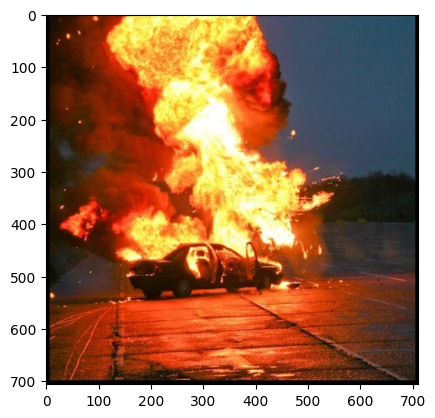

In [5]:


def merge_image(citra1, citra2, orientation='H'): 
    if len(citra1.shape) == 2 and len(citra2.shape) == 3: 
        citra1 = cv2.cvtColor(citra1, cv2.COLOR_GRAY2BGR) 
    elif len(citra1.shape) == 3 and len(citra2.shape) == 2: 
        citra2 = cv2.cvtColor(citra2, cv2.COLOR_GRAY2BGR) 
 
    if orientation == 'H':   
        tinggi = max(citra1.shape[0], citra2.shape[0]) 
        lebar_total = citra1.shape[1] + citra2.shape[1] 
        if len(citra1.shape) == 2: 
            gabungan = np.zeros((tinggi, lebar_total), dtype=citra1.dtype) 
        else: 
            gabungan = np.zeros((tinggi, lebar_total, citra1.shape[2]), dtype=citra1.dtype) 
        gabungan[0:citra1.shape[0], 0:citra1.shape[1]] = citra1 
        gabungan[0:citra2.shape[0], citra1.shape[1]:citra1.shape[1]+citra2.shape[1]] = citra2 
    elif orientation == 'V':   
        tinggi_total = citra1.shape[0] + citra2.shape[0] 
        lebar = max(citra1.shape[1], citra2.shape[1]) 
        if len(citra1.shape) == 2: 
            gabungan = np.zeros((tinggi_total, lebar), dtype=citra1.dtype) 
        else: 
            gabungan = np.zeros((tinggi_total, lebar, citra1.shape[2]), dtype=citra1.dtype) 
        gabungan[0:citra1.shape[0], 0:citra1.shape[1]] = citra1 
        gabungan[citra1.shape[0]:citra1.shape[0]+citra2.shape[0], 0:citra2.shape[1]] = citra2 
    else: 
        raise ValueError("Orientation must be 'H' or 'V'") 
    return gabungan 

gabung1=merge_image(kiri_atas,kanan_atas)
gabung2=merge_image(kiri_bawah,kanan_bawah)
gabung3=merge_image(gabung1,gabung2,'V')

plt.imshow(gabung3)

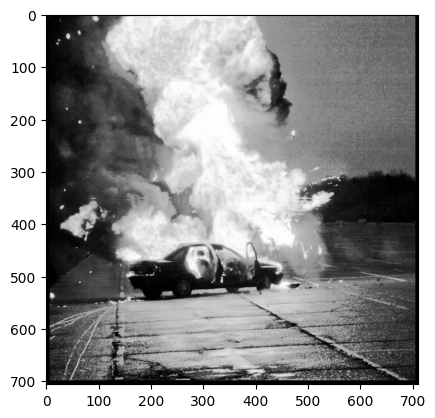

In [6]:
gray = cv2.cvtColor(gabung3, cv2.COLOR_RGB2GRAY)

def ekualisasi(citra): 
    height, width = citra.shape 
 
    hist = np.zeros(256, dtype=int) 
    for y in range(height):
        for x in range(width):
            hist[citra[y, x]] += 1
 
    cdf = np.zeros(256, dtype=int) 
    cdf[0] = hist[0] 
    for i in range(1, 256):
        cdf[i] = cdf[i - 1] + hist[i]
 
    cdf_normal = np.round(cdf * 255 / (height * width)).astype(np.uint8) 
 
    hasil = np.zeros_like(citra, dtype=np.uint8) 
    for y in range(height):
        for x in range(width):
            hasil[y, x] = cdf_normal[citra[y, x]]
 
    return hasil 
 
# Cara manggil: hasil_ekualisasi = ekualisasi(citra_kalian)
hasil_ekualisasi = ekualisasi(gray)

plt.imshow(hasil_ekualisasi, cmap='gray')
plt.show()

In [11]:
def buat_hist(citra): 
    histogram = [0] * 256 
 
    height = len(citra) 
    width = len(citra[0]) if height > 0 else 0 
    for i in range(height): 
        for j in range(width): 
            val = int(citra[i][j])   
            histogram[val] += 1   
 
    return histogram 

def plot_histogram(histogram, title, ImgColor): 
    plt.figure(figsize=(10, 5)) 
    plt.xlabel("Intensitas Piksel") 
    plt.title(title) 
    plt.ylabel("Jumlah Piksel") 
    plt.bar(range(256), histogram, color=ImgColor, width=0.8) 

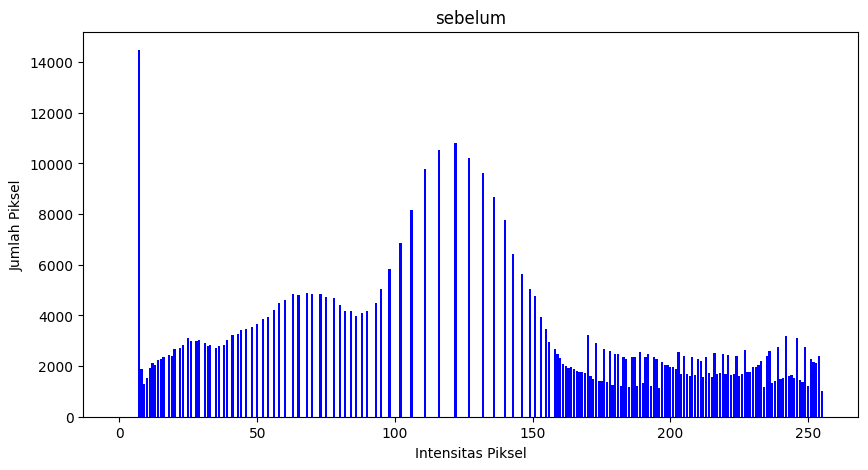

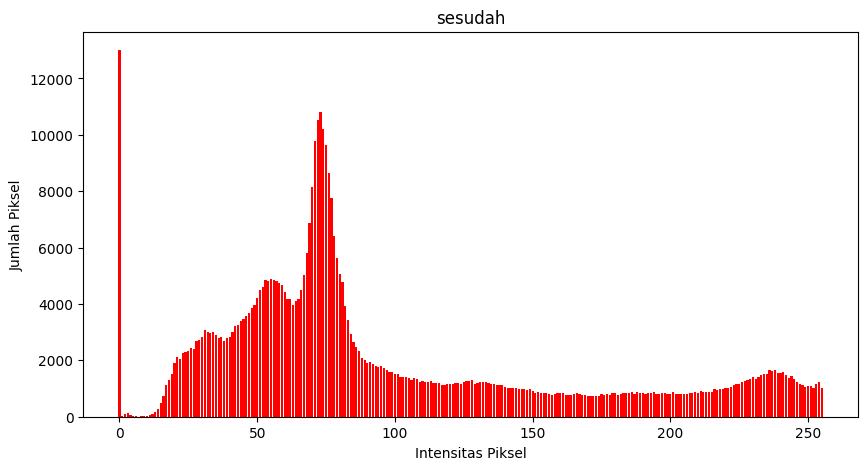

In [13]:
histogram_sebelum = buat_hist(hasil_ekualisasi)
histogram_sesudah = buat_hist(gray)

plot_histogram(histogram_sebelum, "sebelum", "blue")
plt.show
plot_histogram(histogram_sesudah, "sesudah", "red")
plt.show()

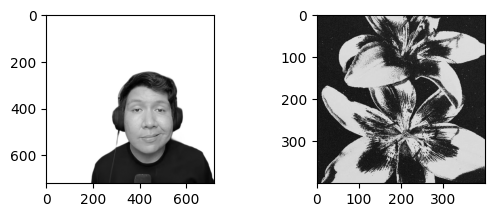

In [9]:
brando =cv2.imread('Assets/Windut.png', cv2.IMREAD_GRAYSCALE)
bunga =cv2.imread('Assets/Bunga.png', cv2.IMREAD_GRAYSCALE)

plt.subplot(2,2,1)
plt.imshow(brando, cmap='gray')
plt.subplot(2,2,2)
plt.imshow(bunga, cmap='gray')

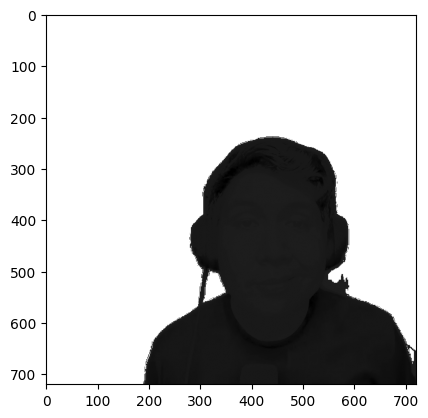

In [16]:

def spesifikasi_histogram(citra_asal, citra_target): 
    hist_asal = np.zeros(256, dtype=int) 
    hist_target = np.zeros(256, dtype=int) 
 
    for y in range(citra_asal.shape[0]):
        for x in range(citra_asal.shape[1]):
            hist_asal[citra_asal[y, x]] += 1
 
    for y in range(citra_target.shape[0]):
        for x in range(citra_target.shape[1]):
            hist_target[citra_target[y, x]] += 1
 
    cdf_asal = np.zeros(256, dtype=float) 
    cdf_target = np.zeros(256, dtype=float) 
 
    cdf_asal[0] = hist_asal[0] 
    cdf_target[0] = hist_target[0] 
    for i in range(1, 256):
        cdf_asal[i] = cdf_asal[i - 1] + hist_asal[i]
        cdf_target[i] = cdf_target[i - 1] + hist_target[i]
 
    cdf_asal = cdf_asal / cdf_asal[-1] 
    cdf_target = cdf_target / cdf_target[-1] 
 
    map_hist = np.zeros(256, dtype=np.uint8) 
    for i in range(256):
        diff = np.abs(cdf_target - cdf_asal[i])
        map_hist[i] = np.argmin(diff)
 
    height, width = citra_asal.shape 
    hasil = np.zeros((height, width), dtype=np.uint8) 
    for y in range(height):
        for x in range(width):
            hasil[x, y] = map_hist[citra_asal[x, y]]
 
    return hasil 

spesipik = spesifikasi_histogram(brando, bunga)

plt.imshow(spesipik, cmap='gray')
plt.show()
